In [ ]:
!pip install imbalanced-learn shap

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
# .................................................................
# 1. Load + treat impossible zeros as missing
# .................................................................
df = pd.read_csv('/content/diabetes.csv')
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
print(df.isna().sum())

X = df.drop(columns='Outcome')
y = df['Outcome']

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [3]:
# .................................................................
# 2. Split FIRST (stratified), so nothing from the test set leaks
#    into imputation, scaling or SMOTE
# .................................................................
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

def make_pipe(clf):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('smote', SMOTE(random_state=1)),
        ('clf', clf),
    ])

In [4]:
# .................................................................
# 3. Baseline: linear SVM, no SMOTE, no tuning (for comparison table)
# .................................................................
baseline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', SVC(kernel='linear')),
]).fit(X_train, y_train)
print("\n=== BASELINE (linear SVM) ===")
print(classification_report(y_test, baseline.predict(X_test),
                            target_names=['Non-Diabetic', 'Diabetic']))



=== BASELINE (linear SVM) ===
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.92      0.84       100
    Diabetic       0.76      0.48      0.59        54

    accuracy                           0.77       154
   macro avg       0.77      0.70      0.71       154
weighted avg       0.77      0.77      0.75       154



In [5]:
# .................................................................
# 4. SMOTE + GridSearchCV on SVM (5-fold CV, scored by F1)
# .................................................................
svm_pipe = make_pipe(SVC(probability=True, random_state=1))
param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['linear', 'rbf'],
    'clf__gamma': ['scale', 0.01, 0.1],   # ignored by linear kernel
}
grid = GridSearchCV(svm_pipe, param_grid, scoring='f1', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))
best_svm = grid.best_estimator_.named_steps['clf']   # tuned SVC (with best params)


Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Best CV F1 : 0.6924


In [6]:
# .................................................................
# 5. Voting ensemble: tuned SVM + Random Forest + MLP (soft voting)
# .................................................................
ensemble = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('rf', RandomForestClassifier(n_estimators=300, random_state=1)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=1)),
    ],
    voting='soft')
ens_pipe = make_pipe(ensemble).fit(X_train, y_train)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== 5-FOLD CV (training data) ===
Tuned SVM (SMOTE) {'accuracy': np.float64(0.772), 'precision': np.float64(0.658), 'recall': np.float64(0.738), 'f1': np.float64(0.692), 'roc_auc': np.float64(0.844)}


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Ensemble (SMOTE) {'accuracy': np.float64(0.756), 'precision': np.float64(0.644), 'recall': np.float64(0.673), 'f1': np.float64(0.657), 'roc_auc': np.float64(0.844)}

=== HELD-OUT TEST SET ===

Tuned SVM (SMOTE)  |  ROC-AUC = 0.823
[[79 21]
 [18 36]]
              precision    recall  f1-score   support

Non-Diabetic       0.81      0.79      0.80       100
    Diabetic       0.63      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


Ensemble (SMOTE)  |  ROC-AUC = 0.830
[[77 23]
 [20 34]]
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.77      0.78       100
    Diabetic       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



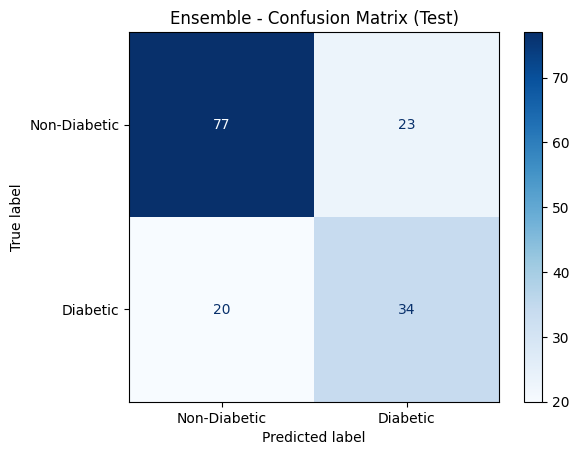

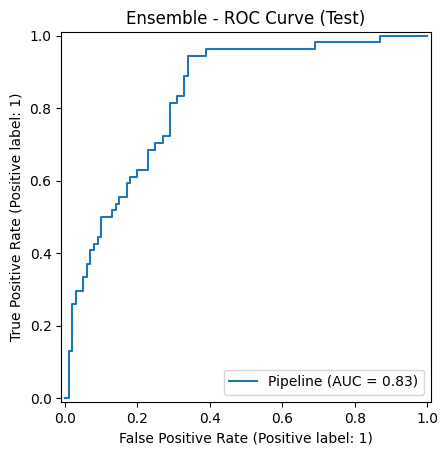

In [7]:
# .................................................................
# 6. Evaluation: 5-fold CV on training data + held-out test set
# .................................................................
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
models = {'Tuned SVM (SMOTE)': grid.best_estimator_, 'Ensemble (SMOTE)': ens_pipe}

print("\n=== 5-FOLD CV (training data) ===")
for name, m in models.items():
    res = cross_validate(m, X_train, y_train, cv=cv, scoring=scoring)
    print(name, {k: round(res[f'test_{k}'].mean(), 3) for k in scoring})

print("\n=== HELD-OUT TEST SET ===")
for name, m in models.items():
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    print(f"\n{name}  |  ROC-AUC = {roc_auc_score(y_test, proba):.3f}")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=['Non-Diabetic', 'Diabetic']))

ConfusionMatrixDisplay.from_estimator(
    ens_pipe, X_test, y_test, display_labels=['Non-Diabetic', 'Diabetic'], cmap='Blues')
plt.title("Ensemble - Confusion Matrix (Test)")
plt.show()

RocCurveDisplay.from_estimator(ens_pipe, X_test, y_test)
plt.title("Ensemble - ROC Curve (Test)")
plt.show()


  0%|          | 0/40 [00:00<?, ?it/s]

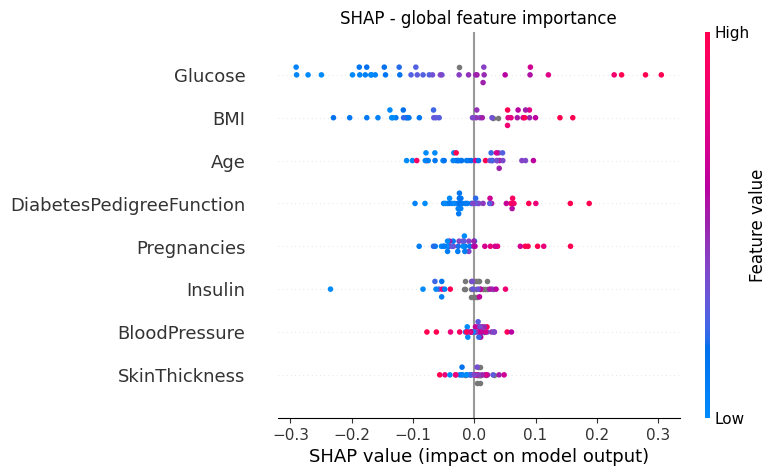

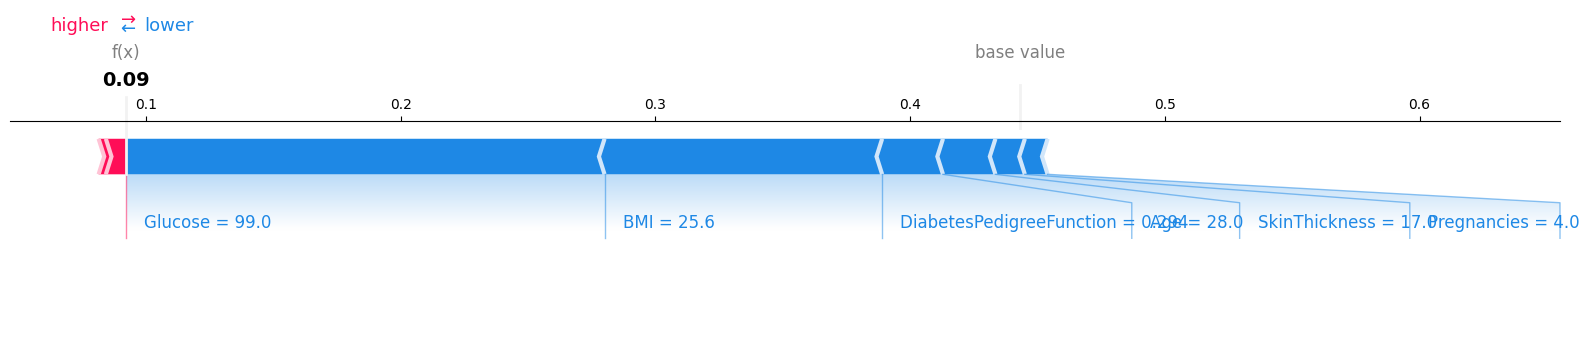

In [8]:
# .................................................................
# 7. SHAP (KernelExplainer on the full pipeline's probability output,
#    so values are in original, readable feature units)
# .................................................................
f = lambda data: ens_pipe.predict_proba(pd.DataFrame(data, columns=X.columns))[:, 1]
background = shap.sample(X_train, 50, random_state=1)
explainer = shap.KernelExplainer(f, background)
X_explain = X_test.iloc[:40]
sv = explainer.shap_values(X_explain)          # shape (40, 8)

shap.summary_plot(sv, X_explain, show=False)    # global importance
plt.title("SHAP - global feature importance")
plt.show()

# Local explanation for one patient (index 0 of X_explain)
shap.force_plot(explainer.expected_value, sv[0], X_explain.iloc[0], matplotlib=True)


In [9]:

# .................................................................
# 8. Save for FastAPI (pipeline already contains imputer + scaler)
# .................................................................
joblib.dump(ens_pipe, 'diabetes_ensemble.joblib')
joblib.dump(background, 'shap_background.joblib')



['shap_background.joblib']

In [10]:
# Example prediction (your original test row, now with no manual scaling)
sample = pd.DataFrame([[2, 197, 70, 45, 543, 30.5, 0.158, 53]], columns=X.columns)
p = ens_pipe.predict_proba(sample)[0, 1]
print(f"\nDiabetic probability: {p:.2f} ->", "Diabetic" if p >= 0.5 else "Non-Diabetic")


Diabetic probability: 0.95 -> Diabetic
